In [5]:
pip install yt-dlp

   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   ---------------------------- ----------- 2.4/3.3 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------- 3.3/3.3 MB 10.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [7]:
import yt_dlp

video_url = 'https://youtu.be/TSi0iJYSQ24?si=gZC0K8TgpMQhLeqy'

ydl_opts = {
    'outtmpl': 'downloaded_video.mp4',  # Save as this file name
    'format': 'best',                   # Download the best quality
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([video_url])

print("✅ Video downloaded successfully!")

[youtube] Extracting URL: https://youtu.be/TSi0iJYSQ24?si=gZC0K8TgpMQhLeqy
[youtube] TSi0iJYSQ24: Downloading webpage
[youtube] TSi0iJYSQ24: Downloading tv client config
[youtube] TSi0iJYSQ24: Downloading player 69b31e11-main
[youtube] TSi0iJYSQ24: Downloading tv player API JSON
[youtube] TSi0iJYSQ24: Downloading ios player API JSON
[youtube] TSi0iJYSQ24: Downloading m3u8 information
[info] TSi0iJYSQ24: Downloading 1 format(s): 18
[download] Destination: downloaded_video.mp4
[download] 100% of   11.83MiB in 00:00:01 at 8.64MiB/s   
✅ Video downloaded successfully!


In [9]:
import cv2

# Path to your downloaded video file
video_path = "C:\\Users\\91722\\Desktop\\SPJIMR Mumbai\\My Courses\\Text_Image_Video Analytics using AI\\PPTs\\Session 12\\downloaded_video.mp4"  # Adjust if you used a different filename

# Open the video file using OpenCV
cap = cv2.VideoCapture(video_path)

# Check if the video opened successfully
if not cap.isOpened():
    print("Error: Could not open video.")
else:
    print("Video opened successfully.")

    # Read video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Frame rate (FPS): {fps}")
    print(f"Total frames: {total_frames}")
    print(f"Resolution: {width}x{height}")

Video opened successfully.
Frame rate (FPS): 29.97002997002997
Total frames: 4329
Resolution: 640x360


In [11]:
import os

# Create a folder to store extracted frames
output_dir = "extracted_frames"
os.makedirs(output_dir, exist_ok=True)

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)  # Start from frame 0
frame_number = 0
saved_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if frame_number % 30 == 0:  # Save every 30th frame (~1 frame per second)
        filename = os.path.join(output_dir, f"frame_{frame_number}.jpg")
        cv2.imwrite(filename, frame)
        saved_count += 1

    frame_number += 1

cap.release()
print(f"✅ Done. Saved {saved_count} frames in folder '{output_dir}'.")

✅ Done. Saved 145 frames in folder 'extracted_frames'.


In [33]:
from ultralytics import YOLO
import cv2
import os

# Load pretrained YOLOv5 model (can use YOLOv8 too)
model = YOLO("yolov5s.pt")  # 's' = small model; fast & good enough

# Path to extracted frames
frame_dir = "extracted_frames"
output_dir = "detected_frames"
os.makedirs(output_dir, exist_ok=True)

# Run detection on each frame
for file in sorted(os.listdir(frame_dir)):
    if file.endswith(".jpg"):
        path = os.path.join(frame_dir, file)
        results = model(path)  # Perform detection
        result_img = results[0].plot()  # Annotate the frame

        # Save annotated frame
        output_path = os.path.join(output_dir, file)
        cv2.imwrite(output_path, result_img)

print("✅ Object detection complete. Annotated frames saved.")

PRO TIP  Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.



100%|█████████████████████████████████████████████████████████████████████████████| 17.7M/17.7M [00:01<00:00, 10.2MB/s]


C:\Users\91722\anaconda3\envs\image-pipeline\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


image 1/1 C:\Users\91722\Desktop\SPJIMR Mumbai\My Courses\Text_Image_Video Analytics using AI\PPTs\Session 12\extracted_frames\frame_0.jpg: 384x640 (no detections), 615.8ms
Speed: 14.6ms preprocess, 615.8ms inference, 26.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\91722\Desktop\SPJIMR Mumbai\My Courses\Text_Image_Video Analytics using AI\PPTs\Session 12\extracted_frames\frame_1020.jpg: 384x640 14 persons, 1 sports ball, 444.9ms
Speed: 4.6ms preprocess, 444.9ms inference, 18.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\91722\Desktop\SPJIMR Mumbai\My Courses\Text_Image_Video Analytics using AI\PPTs\Session 12\extracted_frames\frame_1050.jpg: 384x640 7 persons, 420.5ms
Speed: 3.4ms preprocess, 420.5ms inference, 4.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\91722\Desktop\SPJIMR Mumbai\My Courses\Text_Image_Video Analytics using AI\PPTs\Session 12\extracted_frames\frame_1080.jpg: 384x640 8 persons, 2 birds, 

In [35]:
import cv2
import os

# Path to detected frames
input_folder = "detected_frames"
output_video = "detected_output_video.mp4"

# Get frame list (sorted to maintain order)
frame_files = sorted([f for f in os.listdir(input_folder) if f.endswith(".jpg")])

# Read the first frame to get dimensions
first_frame = cv2.imread(os.path.join(input_folder, frame_files[0]))
height, width, layers = first_frame.shape
fps = 30  # You can adjust this if needed

# Define the video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec
video_writer = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

# Write frames into video
for file in frame_files:
    frame_path = os.path.join(input_folder, file)
    frame = cv2.imread(frame_path)
    video_writer.write(frame)

video_writer.release()
print(f"✅ Video saved as '{output_video}'")

✅ Video saved as 'detected_output_video.mp4'


In [37]:
import cv2
import os

# Path to detected frames
input_folder = "detected_frames"
output_video = "detected_output_video_3s_per_frame.mp4"

# Get frame list
frame_files = sorted([f for f in os.listdir(input_folder) if f.endswith(".jpg")])

# Read the first frame to get dimensions
first_frame = cv2.imread(os.path.join(input_folder, frame_files[0]))
height, width, _ = first_frame.shape

# Set target FPS and duration per frame
fps = 30
duration_per_frame = 3  # seconds
frame_repeats = int(fps * duration_per_frame)  # Number of times to repeat each frame

# Define video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_writer = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

# Write each frame multiple times
for file in frame_files:
    frame_path = os.path.join(input_folder, file)
    frame = cv2.imread(frame_path)

    for _ in range(frame_repeats):
        video_writer.write(frame)

video_writer.release()
print(f"✅ Slow-play video saved as '{output_video}' (3s per frame)")

✅ Slow-play video saved as 'detected_output_video_3s_per_frame.mp4' (3s per frame)


In [39]:
from ultralytics import YOLO
import os
from collections import defaultdict
import matplotlib.pyplot as plt

# Load model
model = YOLO("yolov5s.pt")

# Path to frames
frame_dir = "extracted_frames"
frame_files = sorted([f for f in os.listdir(frame_dir) if f.endswith(".jpg")])

# Initialize counters
class_counts = defaultdict(int)
frame_object_counts = []

for file in frame_files:
    path = os.path.join(frame_dir, file)
    results = model(path)
    detections = results[0].boxes

    frame_count = 0
    for box in detections:
        cls_id = int(box.cls.item())
        cls_name = model.names[cls_id]
        class_counts[cls_name] += 1
        frame_count += 1
    
    frame_object_counts.append((file, frame_count))

print("✅ Detection summary complete.")

PRO TIP  Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


image 1/1 C:\Users\91722\Desktop\SPJIMR Mumbai\My Courses\Text_Image_Video Analytics using AI\PPTs\Session 12\extracted_frames\frame_0.jpg: 384x640 (no detections), 426.6ms
Speed: 4.3ms preprocess, 426.6ms inference, 2.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\91722\Desktop\SPJIMR Mumbai\My Courses\Text_Image_Video Analytics using AI\PPTs\Session 12\extracted_frames\frame_1020.jpg: 384x640 14 persons, 1 sports ball, 430.5ms
Speed: 4.5ms preprocess, 430.5ms inference, 5.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\91722\Desktop\SPJIMR Mumbai\My Courses\Text_Image_Video Analytics using AI\PPTs\Session 12\extracted_frames\frame_1050.jpg: 384x640 7 persons, 396.6ms
Speed: 3.2ms pre


🎯 Top Detected Object Classes:
person: 742 instances
sports ball: 35 instances
tv: 20 instances
couch: 3 instances
bird: 2 instances
car: 2 instances
remote: 2 instances
frisbee: 2 instances
chair: 2 instances
baseball bat: 2 instances
potted plant: 1 instances
bowl: 1 instances
tennis racket: 1 instances
cell phone: 1 instances
baseball glove: 1 instances
bottle: 1 instances
tie: 1 instances
kite: 1 instances
umbrella: 1 instances
skateboard: 1 instances
train: 1 instances


C:\Users\91722\AppData\Local\Temp\ipykernel_8540\2197768375.py:19: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\91722\anaconda3\envs\image-pipeline\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


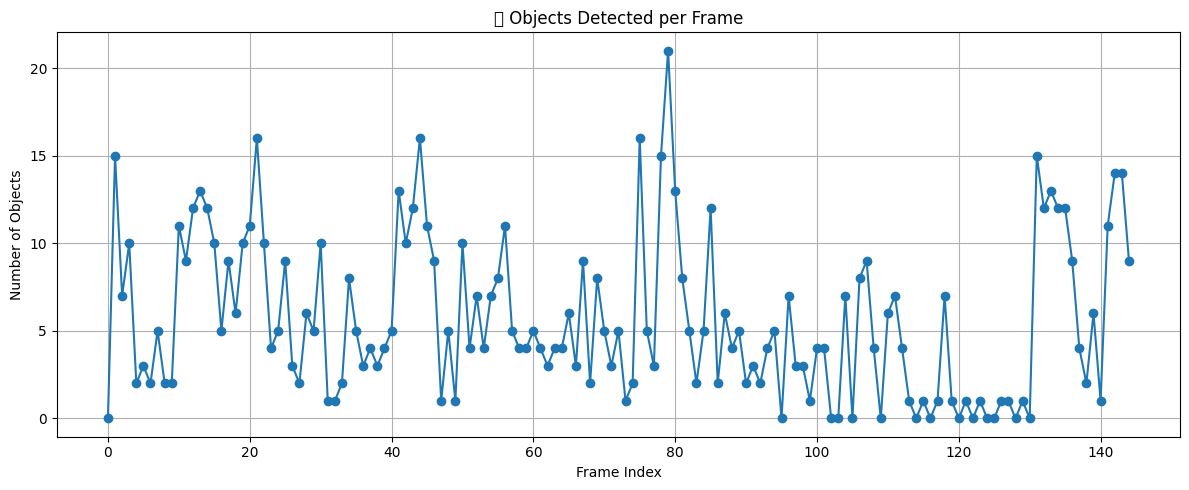

In [41]:
# Sort and show top classes
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

print("\n🎯 Top Detected Object Classes:")
for cls, count in sorted_classes:
    print(f"{cls}: {count} instances")

# Frame-wise object count trend
frame_names = [f for f, _ in frame_object_counts]
object_counts = [count for _, count in frame_object_counts]

# Plot objects per frame
plt.figure(figsize=(12, 5))
plt.plot(object_counts, marker='o')
plt.title("📈 Objects Detected per Frame")
plt.xlabel("Frame Index")
plt.ylabel("Number of Objects")
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
from ultralytics import YOLO
import os
import shutil

# Load model
model = YOLO("yolov5s.pt")

# Source and target folders
input_folder = "extracted_frames"
output_folder = "frames_with_sports_ball"
os.makedirs(output_folder, exist_ok=True)

# Go through each frame
for file in sorted(os.listdir(input_folder)):
    if file.endswith(".jpg"):
        path = os.path.join(input_folder, file)
        results = model(path)
        detections = results[0].boxes

        # Check if 'sports ball' is in this frame
        for box in detections:
            cls_id = int(box.cls.item())
            cls_name = model.names[cls_id]

            if cls_name == "sports ball":
                shutil.copy(path, os.path.join(output_folder, file))
                break  # No need to check further boxes

print("✅ All frames containing 'sports ball' copied to 'frames_with_sports_ball'.")

PRO TIP  Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


image 1/1 C:\Users\91722\Desktop\SPJIMR Mumbai\My Courses\Text_Image_Video Analytics using AI\PPTs\Session 12\extracted_frames\frame_0.jpg: 384x640 (no detections), 404.1ms
Speed: 4.0ms preprocess, 404.1ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\91722\Desktop\SPJIMR Mumbai\My Courses\Text_Image_Video Analytics using AI\PPTs\Session 12\extracted_frames\frame_1020.jpg: 384x640 14 persons, 1 sports ball, 421.3ms
Speed: 3.2ms preprocess, 421.3ms inference, 5.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\91722\Desktop\SPJIMR Mumbai\My Courses\Text_Image_Video Analytics using AI\PPTs\Session 12\extracted_frames\frame_1050.jpg: 384x640 7 persons, 436.0ms
Speed: 3.9ms pre

In [47]:
import sys
!{sys.executable} -m pip install pytesseract

  Using cached pytesseract-0.3.13-py3-none-any.whl.metadata (11 kB)
Using cached pytesseract-0.3.13-py3-none-any.whl (14 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [49]:
import pytesseract

# Set the path to your installed tesseract executable
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [55]:
from PIL import Image
import pandas as pd

# Folder with frames where ball is detected
frame_folder = "frames_with_sports_ball"

# Initialize list to hold results
data = []

# Loop through each frame
for filename in sorted(os.listdir(frame_folder)):
    if filename.endswith(".jpg"):
        frame_path = os.path.join(frame_folder, filename)

        # Read and preprocess image
        img = cv2.imread(frame_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

        # Convert to PIL for Tesseract
        pil_img = Image.fromarray(thresh)

        # OCR text extraction
        extracted_text = pytesseract.image_to_string(pil_img)

        # Add to table
        data.append({"Frame": filename, "Extracted_Text": extracted_text.strip()})

# Convert to DataFrame
df = pd.DataFrame(data)

# Display the table
import pandas as pd
import IPython.display as disp
disp.display(df)

,Frame,Extracted_Text
0,frame_1020.jpg,
1,frame_1260.jpg,
2,frame_1320.jpg,JEFA CHAMPIONS LEAGUE | Cfo FA ALLEN EN NN RAE...
3,frame_1350.jpg,ON ME FA RUINED
4,frame_1380.jpg,They got that from met
5,frame_1500.jpg,eo Dynamic\nDribbling « >
6,frame_1530.jpg,
7,frame_1950.jpg,
8,frame_2010.jpg,Passing feels sluggit\nRetunin\ncog:\n\nonus
9,frame_2100.jpg,39:00 Ao\n\nFy\n\nBe amass


In [57]:
import pandas as pd
import re

# Load the existing DataFrame if needed
# df = pd.read_csv("frame_text_summary.csv")

def clean_text(text):
    if not text or pd.isna(text):
        return ""
    
    # Remove line breaks and extra whitespace
    text = re.sub(r"\n+", " ", text)
    
    # Remove special characters that are not useful
    text = re.sub(r"[^A-Za-z0-9\s:!?'.-]", "", text)
    
    # Collapse multiple spaces
    text = re.sub(r"\s{2,}", " ", text)
    
    # Strip leading/trailing spaces
    return text.strip()

# Apply cleaning
df["Cleaned_Text"] = df["Extracted_Text"].apply(clean_text)

# Filter non-empty cleaned rows
df_filtered = df[df["Cleaned_Text"].str.len() > 0]

# Show cleaned results
import IPython.display as disp
disp.display(df_filtered[["Frame", "Cleaned_Text"]])

,Frame,Cleaned_Text
2,frame_1320.jpg,JEFA CHAMPIONS LEAGUE Cfo FA ALLEN EN NN RAE B...
3,frame_1350.jpg,ON ME FA RUINED
4,frame_1380.jpg,They got that from met
5,frame_1500.jpg,eo Dynamic Dribbling
8,frame_2010.jpg,Passing feels sluggit Retunin cog: onus
9,frame_2100.jpg,39:00 Ao Fy Be amass
10,frame_2160.jpg,Ee 2530 Een
12,frame_2250.jpg,Fy 300: a cara he Rainbo Ww
14,frame_2820.jpg,fa 20:4 Le On-Ball Physicality
18,frame_3120.jpg,eo nae tHe . Da PSE INDATON vo : at Le TO NB e...


In [59]:
#------------------------Expected----------------------------------
# 1) Way too many bounce backs
# 2) Cleaner standing tackles
# 3) Fix tackles!!!
# 4) On-ball physicality
# 5) Passing feels sluggish
# 6) And that's just the start

In [61]:
import numpy as np

# object_counts is the list you already plotted
diffs = np.abs(np.diff(object_counts))
threshold = np.percentile(diffs, 90)        # top 10 % jumps
cut_points = np.where(diffs > threshold)[0] # frame indices where scene likely changes
print("Possible shot boundaries at frames:", cut_points.tolist())

Possible shot boundaries at frames: [0, 9, 30, 49, 74, 75, 77, 85, 130, 140]


In [63]:
N = 10
top_idx = np.argsort(object_counts)[-N:]
highlight_dir = "highlight_frames"
os.makedirs(highlight_dir, exist_ok=True)

for i in top_idx:
    src = os.path.join("detected_frames", frame_files[i])
    dst = os.path.join(highlight_dir, frame_files[i])
    shutil.copy(src, dst)

In [65]:
# --------- 1. Detect shot boundaries from object-count jumps ----------
import numpy as np, cv2, os, shutil, matplotlib.pyplot as plt

diffs = np.abs(np.diff(object_counts))
thr   = np.percentile(diffs, 90)
cuts  = np.where(diffs > thr)[0]

print("Shot-change frames:", cuts.tolist())

# --------- 2. Extract thumbnails for a storyboard ----------
story_dir = "storyboard"
os.makedirs(story_dir, exist_ok=True)

for idx in cuts:
    f = frame_files[idx+1]          # frame right after the jump
    shutil.copy(os.path.join("detected_frames", f),
                os.path.join(story_dir, f))

print("Storyboard images saved to", story_dir)

# --------- 3. Grab top-10 busiest frames ----------
top10 = np.argsort(object_counts)[-10:]
busy_dir = "busiest_frames"
os.makedirs(busy_dir, exist_ok=True)

for idx in top10:
    f = frame_files[idx]
    shutil.copy(os.path.join("detected_frames", f),
                os.path.join(busy_dir, f))

print("Top-10 busy frames saved to", busy_dir)

Shot-change frames: [0, 9, 30, 49, 74, 75, 77, 85, 130, 140]
Storyboard images saved to storyboard
Top-10 busy frames saved to busiest_frames


In [67]:
# Storyboard Frames: Key frames that represent visual transitions between scenes, 
# typically extracted right after major shot changes to summarize the video sequence.

# Busy Frames: Frames with the highest number of detected objects, indicating visually dense or high-action moments in the video.

# Shot-Change Frames: Frames where there is a sudden spike in object count difference, signaling a likely camera cut or scene transition.

In [69]:
# --------------------------------Structure of Storytelling-----------------------------------------------------
# Feature announcements or promotions (like "Signature Perks", "Cleaner Tackles").
# Gameplay highlights (crowd, ball movement, goal attempts).
# Branding or title screens (e.g., “Man City vs Liverpool”).
# Reactions and cinematic close-ups of players.

In [73]:
import sys
!{sys.executable} -m pip install wordcloud

  Using cached wordcloud-1.9.4-cp310-cp310-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.4-cp310-cp310-win_amd64.whl (299 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [75]:
import sys
!{sys.executable} -m pip install nltk

  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\91722\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91722\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\91722\anaconda3\envs\image-pipeline\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


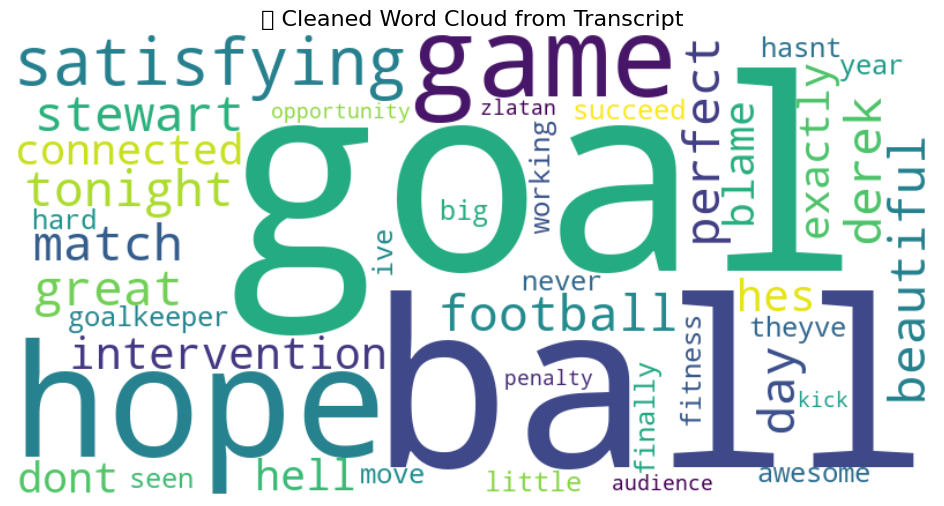

In [87]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import re

# Download stopwords if not already done
nltk.download('punkt')
nltk.download('stopwords')

# Input: commentary transcript
transcript = """
Oh, it's a beautiful day for football. I hope we see a great match, Stewart. I hope we actually get to see the game tonight, Derek. This is more satisfying!
It's a perfect intervention. It's like he's connected to the ball! Every goal is exactly the same. The ball goes to him. Goal. The ball goes to him. Goal.
I don't think he'll blame the goalkeeper this year! Yes! Well, it looks like they've been working hard on this, hasn't it? 
Well, I've never seen that move before. Or that one! Oh, finally, a little fitness in this game. Oh, this is more satisfying. 
What a goal, awesome! Can they succeed here? Big opportunity! And a penalty kick! Wait, wait, wait. 
Give the audience what they want. Give them Zlatan.
"""

# Step 1: Lowercase the text
text = transcript.lower()

# Step 2: Remove punctuation & numbers
text = re.sub(r'[^a-z\s]', '', text)

# Step 3: Tokenize
tokens = word_tokenize(text)

# Step 4: Remove standard and custom stopwords
default_stopwords = set(stopwords.words('english'))
custom_stopwords = {
    'oh', 'yes', 'well', 'one', 'get', 'looks', 'see', 'actually', 'give', 
    'just', 'like', 'want', 'wait', 'every', 'think', 'got', 'goes', 'let'
}
all_stopwords = default_stopwords.union(custom_stopwords)

# Step 5: Filter tokens
filtered_tokens = [word for word in tokens if word not in all_stopwords]

# Step 6: Join words for word cloud
cleaned_text = ' '.join(filtered_tokens)

# Step 7: Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(cleaned_text)

# Step 8: Show plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("🎯 Cleaned Word Cloud from Transcript", fontsize=16)
plt.show()

C:\Users\91722\AppData\Local\Temp\ipykernel_8540\4113681411.py:71: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\91722\anaconda3\envs\image-pipeline\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


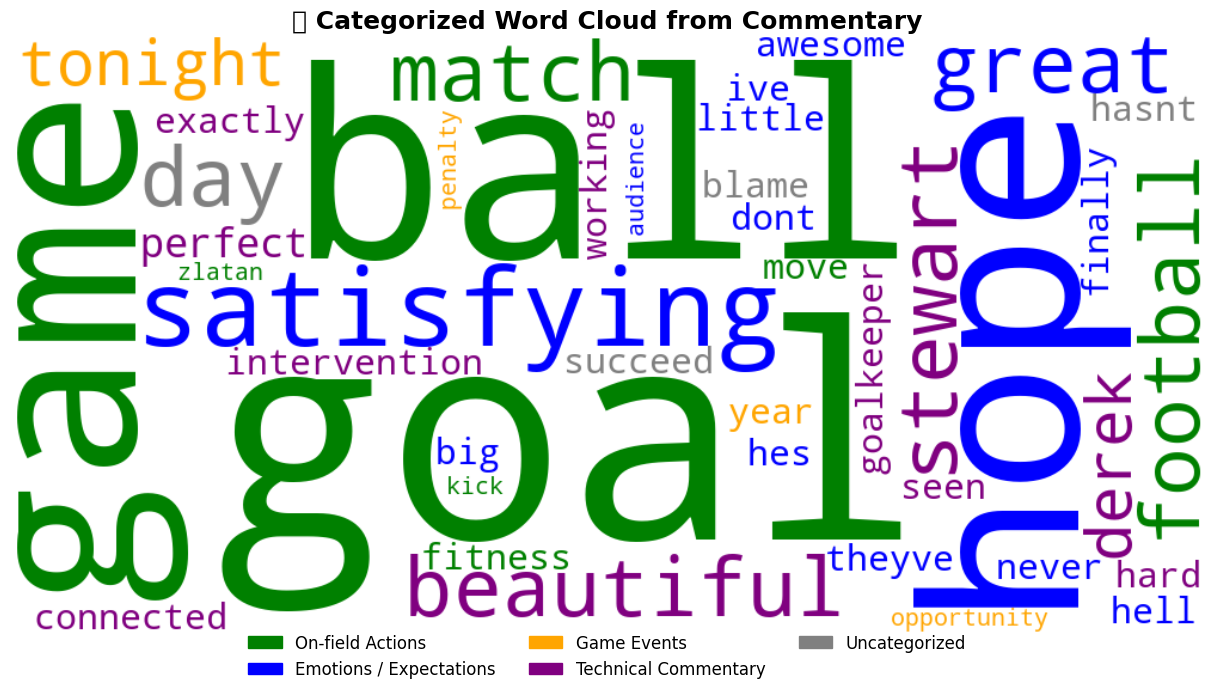

In [101]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.patches as mpatches



# --- Step 1: Define category keywords and colors ---
category_keywords = {
    'On-field Actions': {
        'color': 'green',
        'keywords': {'goal', 'ball', 'game', 'football', 'kick', 'fitness', 'move', 'zlatan', 'match'}
    },
    'Emotions / Expectations': {
        'color': 'blue',
        'keywords': {'hope', 'satisfying', 'great', 'awesome', 'dont', 'theyve', 'hes', 'never', 'hell', 'finally', 'ive', 'little', 'big', 'audience'}
    },
    'Game Events': {
        'color': 'orange',
        'keywords': {'tonight', 'penalty', 'opportunity', 'year'}
    },
    'Technical Commentary': {
        'color': 'purple',
        'keywords': {'connected', 'intervention', 'working', 'exactly', 'goalkeeper', 'beautiful', 'perfect', 'seen', 'hard', 'stewart', 'derek'}
    }
}

# --- Step 2: Color function for word categories ---
def categorize_word(word):
    word = word.lower()
    for category, data in category_keywords.items():
        if word in data['keywords']:
            return data['color']
    return 'gray'  # Uncategorized

def category_color_func(word, *args, **kwargs):
    return categorize_word(word)

# --- Step 3: Generate WordCloud ---
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    color_func=category_color_func,
    max_words=100
).generate(cleaned_text)

# --- Step 4: Plot WordCloud with Category Legend ---
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title("🎯 Categorized Word Cloud from Commentary", fontsize=18, fontweight='bold')

# --- Step 5: Create and show legend ---
legend_patches = [
    mpatches.Patch(color='green', label='On-field Actions'),
    mpatches.Patch(color='blue', label='Emotions / Expectations'),
    mpatches.Patch(color='orange', label='Game Events'),
    mpatches.Patch(color='purple', label='Technical Commentary'),
    mpatches.Patch(color='gray', label='Uncategorized')
]

ax.legend(
    handles=legend_patches,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    fontsize=12,
    frameon=False
)

plt.tight_layout()
plt.show()

In [103]:
# Media Strategy + AI/ML + Consumer Behavior + Data Storytelling